# Assignment 3 Solution: Hybrid Semantic Retrieval & Intelligence System (HSRIS)

This notebook implements a **distinct, original solution** for the customer-support retrieval assignment using:
- from-scratch categorical encoders
- from-scratch sparse TF-IDF retrieval
- GloVe-based dense semantic retrieval
- hybrid scoring
- quantitative + qualitative evaluation

Dataset is added directly through Kaggle.

In [3]:
import os
import re
import math
import time
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    print("GPU name:", torch.cuda.get_device_name(0))

Device: cuda
GPU count: 2
GPU name: Tesla T4


In [4]:
DATA_PATH = "/kaggle/input/datasets/waseemalastal/customer-support-ticket-dataset/customer_support_tickets.csv"
GLOVE_PATH = "/kaggle/input/datasets/rtatman/glove-global-vectors-for-word-representation/glove.6B.100d.txt"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head(3))

Shape: (8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0


## Part 1 — Categorical Foundation

In [5]:
# 1a) Ordinal label encoding (from scratch): Ticket Priority
priority_order = ["Low", "Medium", "High", "Critical"]
priority_to_id = {name: idx for idx, name in enumerate(priority_order)}

def encode_priority(x):
    if pd.isna(x):
        return -1
    return priority_to_id.get(str(x).strip(), -1)

df["priority_id"] = df["Ticket Priority"].apply(encode_priority).astype(int)

id_to_priority = {v: k for k, v in priority_to_id.items()}
print("Priority mapping:", priority_to_id)
display(df[["Ticket Priority", "priority_id"]].head(10))

Priority mapping: {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}


,Ticket Priority,priority_id
0,Critical,3
1,Critical,3
2,Low,0
3,Low,0
4,Low,0
5,Low,0
6,Critical,3
7,Critical,3
8,Low,0
9,Critical,3


In [6]:
# 1b) One-hot encoding (from scratch): Ticket Channel
channels = sorted(df["Ticket Channel"].dropna().astype(str).unique().tolist())
channel_to_idx = {c: i for i, c in enumerate(channels)}

def one_hot_channel(value, categories):
    vec = [0] * len(categories)
    if pd.notna(value):
        v = str(value).strip()
        if v in channel_to_idx:
            vec[channel_to_idx[v]] = 1
    return vec

one_hot_matrix = df["Ticket Channel"].apply(lambda x: one_hot_channel(x, channels))
for c, i in channel_to_idx.items():
    safe = c.lower().replace(" ", "_")
    df[f"channel_{safe}"] = one_hot_matrix.apply(lambda row: row[i])

print("Channels:", channels)
display(df[["Ticket Channel"] + [f"channel_{c.lower().replace(' ', '_')}" for c in channels]].head(8))
print("Unseen category test (Fax):", one_hot_channel("Fax", channels))

Channels: ['Chat', 'Email', 'Phone', 'Social media']


,Ticket Channel,channel_chat,channel_email,channel_phone,channel_social_media
0,Social media,0,0,0,1
1,Chat,1,0,0,0
2,Social media,0,0,0,1
3,Social media,0,0,0,1
4,Email,0,1,0,0
5,Social media,0,0,0,1
6,Social media,0,0,0,1
7,Social media,0,0,0,1


Unseen category test (Fax): [0, 0, 0, 0]


## Part 2 — Sparse Retrieval (Keyword Intelligence)

In [7]:
# Build textual document per ticket (vectorized, Series-safe)
df["doc_raw"] = (
    df["Ticket Subject"].fillna("").astype(str) + ". " +
    df["Ticket Description"].fillna("").astype(str) + ". " +
    df["Resolution"].fillna("").astype(str)
)

display(df[["Ticket Subject", "Ticket Description", "doc_raw"]].head(3))

,Ticket Subject,Ticket Description,doc_raw
0,Product setup,I'm having an issue with the {product_purchase...,Product setup. I'm having an issue with the {p...
1,Peripheral compatibility,I'm having an issue with the {product_purchase...,Peripheral compatibility. I'm having an issue ...
2,Network problem,I'm facing a problem with my {product_purchase...,Network problem. I'm facing a problem with my ...


In [8]:
# Cleaning + tokenization (from scratch)
STOPWORDS = {
    "a","an","the","and","or","but","if","to","of","for","on","in","with","is","are","was","were","be","been","it","this","that","my","your","our","i","im","me","we","you","they","he","she","as","at","from","by","so","can","could","would","should"
}

def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"\{[^{}]*\}", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\b\d{1,4}[-/]\d{1,2}[-/]\d{1,4}(?:\s+\d{1,2}:\d{2}(?::\d{2})?)?\b", " ", text)
    text = re.sub(r"\b\d{1,3}(?:\.\d{1,3}){3}\b", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def light_stem(token):
    # lightweight stemmer-like rules (not nltk, from scratch)
    if len(token) > 5 and token.endswith("ing"):
        return token[:-3]
    if len(token) > 4 and token.endswith("ed"):
        return token[:-2]
    if len(token) > 4 and token.endswith("es"):
        return token[:-2]
    if len(token) > 3 and token.endswith("s"):
        return token[:-1]
    return token

def tokenize(text):
    text = normalize_text(text)
    tokens = []
    for tok in text.split():
        if tok in STOPWORDS:
            continue
        if len(tok) < 3:
            continue
        tok = light_stem(tok)
        if tok and tok not in STOPWORDS and len(tok) >= 3:
            tokens.append(tok)
    return tokens

df["tokens"] = df["doc_raw"].apply(tokenize)
display(df[["doc_raw", "tokens"]].head(3))

,doc_raw,tokens
0,Product setup. I'm having an issue with the {p...,"[product, setup, hav, issue, please, assist, b..."
1,Peripheral compatibility. I'm having an issue ...,"[peripheral, compatibility, hav, issue, please..."
2,Network problem. I'm facing a problem with my ...,"[network, problem, fac, problem, not, turn, wo..."


In [9]:
# Build vocabulary with min_df and max_vocab constraints
MIN_DF = 3
MAX_VOCAB = 6000

doc_freq = Counter()
for toks in df["tokens"]:
    doc_freq.update(set(toks))

candidates = [w for w, d in doc_freq.items() if d >= MIN_DF]
candidates_sorted = sorted(candidates, key=lambda w: doc_freq[w], reverse=True)[:MAX_VOCAB]
word2idx = {w: i for i, w in enumerate(candidates_sorted)}
idx2word = {i: w for w, i in word2idx.items()}
V = len(word2idx)
N = len(df)

print("Documents:", N)
print("Vocabulary size:", V)
print("Sample vocab:", candidates_sorted[:20])

Documents: 8469
Vocabulary size: 2047
Sample vocab: ['issue', 'please', 'hav', 'assist', 'product', 'problem', 'not', 'software', 'any', 'data', 'there', 'other', 'work', 'what', 'support', 'have', 'step', 'troubleshoot', 'updat', 'account']


In [10]:
# Build sparse TF-IDF representation as list of dicts: doc_id -> {term_idx: weight}
idf = np.zeros(V, dtype=np.float32)
for w, i in word2idx.items():
    dfreq = doc_freq[w]
    idf[i] = math.log((N + 1) / (dfreq + 1)) + 1.0

doc_tfidf = []
doc_norms = np.zeros(N, dtype=np.float32)

for doc_id, toks in enumerate(df["tokens"]):
    tf = Counter([t for t in toks if t in word2idx])
    if not tf:
        doc_tfidf.append({})
        continue

    total = sum(tf.values())
    vec = {}
    sq = 0.0
    for t, c in tf.items():
        idx = word2idx[t]
        wt = (c / total) * float(idf[idx])
        vec[idx] = wt
        sq += wt * wt
    norm = math.sqrt(sq) if sq > 0 else 1.0
    for k in list(vec.keys()):
        vec[k] = vec[k] / norm

    doc_tfidf.append(vec)
    doc_norms[doc_id] = 1.0

# Build inverted index: term_idx -> list[(doc_id, normalized_weight)]
inverted_index = defaultdict(list)
for d, vec in enumerate(doc_tfidf):
    for t_idx, wt in vec.items():
        inverted_index[t_idx].append((d, wt))

print("Built TF-IDF sparse matrix as dictionaries.")
print("Indexed terms:", len(inverted_index))

Built TF-IDF sparse matrix as dictionaries.
Indexed terms: 2047


In [11]:
# N-gram helper (from scratch)
def generate_ngrams(tokens, n=2):
    return ["_".join(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

df["bigrams"] = df["tokens"].apply(lambda x: generate_ngrams(x, 2))
df["trigrams"] = df["tokens"].apply(lambda x: generate_ngrams(x, 3))

print("Example bigrams:", df["bigrams"].iloc[0][:8])
print("Example trigrams:", df["trigrams"].iloc[0][:8])

Example bigrams: ['product_setup', 'setup_hav', 'hav_issue', 'issue_please', 'please_assist', 'assist_bill', 'bill_zip', 'zip_code']
Example trigrams: ['product_setup_hav', 'setup_hav_issue', 'hav_issue_please', 'issue_please_assist', 'please_assist_bill', 'assist_bill_zip', 'bill_zip_code', 'zip_code_appreciate']


In [12]:
def build_query_tfidf(query):
    toks = tokenize(query)
    tf = Counter([t for t in toks if t in word2idx])
    if not tf:
        return {}, toks

    total = sum(tf.values())
    qvec = {}
    sq = 0.0
    for t, c in tf.items():
        idx = word2idx[t]
        wt = (c / total) * float(idf[idx])
        qvec[idx] = wt
        sq += wt * wt

    norm = math.sqrt(sq) if sq > 0 else 1.0
    for k in list(qvec.keys()):
        qvec[k] /= norm

    return qvec, toks

def sparse_tfidf_search(query, top_k=5):
    qvec, qtoks = build_query_tfidf(query)
    if not qvec:
        return [], qtoks

    scores = defaultdict(float)
    for t_idx, q_wt in qvec.items():
        for doc_id, d_wt in inverted_index.get(t_idx, []):
            scores[doc_id] += q_wt * d_wt

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
    return ranked, qtoks

tfidf_demo, qtok = sparse_tfidf_search("payment failed twice and refund issue", top_k=5)
print("Query tokens:", qtok)
print("Top TF-IDF results:")
for rank, (idx, score) in enumerate(tfidf_demo, 1):
    print(rank, round(score, 4), "|", df.iloc[idx]["Ticket Type"], "|", df.iloc[idx]["Ticket Subject"])

Query tokens: ['payment', 'fail', 'twice', 'refund', 'issue']
Top TF-IDF results:
1 0.3047 | Technical issue | Product compatibility
2 0.2716 | Cancellation request | Peripheral compatibility
3 0.2523 | Product inquiry | Product compatibility
4 0.2392 | Cancellation request | Refund request
5 0.2221 | Cancellation request | Software bug


## Part 3 — Dense Semantic Retrieval (GloVe + PyTorch)

In [13]:
EMBED_DIM = 100
glove = {}

with open(GLOVE_PATH, "r", encoding="utf8") as f:
    for line in f:
        parts = line.rstrip().split(" ")
        word = parts[0]
        vec = np.asarray(parts[1:], dtype=np.float32)
        glove[word] = vec

print("Loaded GloVe words:", len(glove))
print("Embedding dim:", EMBED_DIM)

Loaded GloVe words: 400000
Embedding dim: 100


In [14]:
# Build dense document embeddings: IDF-weighted average with L2 normalization
def sentence_embedding(tokens):
    vec = np.zeros(EMBED_DIM, dtype=np.float32)
    weight_sum = 0.0

    for t in tokens:
        g = glove.get(t)
        if g is None:
            continue
        if t in word2idx:
            w = float(idf[word2idx[t]])
        else:
            w = 1.0
        vec += w * g
        weight_sum += w

    if weight_sum > 0:
        vec /= weight_sum

    nrm = np.linalg.norm(vec)
    if nrm > 0:
        vec /= nrm
    return vec

doc_semantic = np.vstack([sentence_embedding(toks) for toks in df["tokens"]]).astype(np.float32)
doc_semantic_t = torch.tensor(doc_semantic, dtype=torch.float32, device=device)

print("Semantic matrix:", doc_semantic.shape)

Semantic matrix: (8469, 100)


In [15]:
def semantic_search(query, top_k=5):
    q_tokens = tokenize(query)
    q_vec = sentence_embedding(q_tokens)
    q_t = torch.tensor(q_vec, dtype=torch.float32, device=device).unsqueeze(0)

    # both vectors are normalized, cosine = dot
    sims = torch.mm(q_t, doc_semantic_t.T).squeeze(0)
    vals, idxs = torch.topk(sims, k=top_k)

    results = [(int(i), float(v)) for i, v in zip(idxs.detach().cpu().numpy(), vals.detach().cpu().numpy())]
    return results, q_tokens

sem_demo, sem_qtoks = semantic_search("refund not received after payment", top_k=5)
print("Query tokens:", sem_qtoks)
print("Top Semantic results:")
for rank, (idx, score) in enumerate(sem_demo, 1):
    print(rank, round(score, 4), "|", df.iloc[idx]["Ticket Type"], "|", df.iloc[idx]["Ticket Subject"])

Query tokens: ['refund', 'not', 'receiv', 'after', 'payment']
Top Semantic results:
1 0.8947 | Cancellation request | Payment issue
2 0.8844 | Technical issue | Account access
3 0.8836 | Cancellation request | Payment issue
4 0.8834 | Billing inquiry | Account access
5 0.8821 | Technical issue | Battery life


## Part 4 — Hybrid Retrieval

Assignment logic: **FinalScore = α(TF-IDF Score) + (1 − α)(GloVe Score)** with **α = 0.4**.

In [16]:
def hybrid_search(query, alpha=0.4, top_k=5):
    # Assignment formula: FinalScore = alpha*TFIDF + (1-alpha)*GloVe, with alpha=0.4
    tfidf_ranked, _ = sparse_tfidf_search(query, top_k=len(df))
    sem_ranked, _ = semantic_search(query, top_k=len(df))

    tfidf_scores = np.zeros(len(df), dtype=np.float32)
    sem_scores = np.zeros(len(df), dtype=np.float32)

    for i, s in tfidf_ranked:
        tfidf_scores[i] = s
    for i, s in sem_ranked:
        sem_scores[i] = s

    final = alpha * tfidf_scores + (1.0 - alpha) * sem_scores
    top_idx = np.argsort(-final)[:top_k]
    return [(int(i), float(final[i])) for i in top_idx]

query = "payment failed and I need refund"
hyb = hybrid_search(query, alpha=0.4, top_k=5)
print("Hybrid results for query:", query)
for rank, (idx, score) in enumerate(hyb, 1):
    row = df.iloc[idx]
    print(f"{rank}. score={score:.4f} | {row['Ticket Type']} | {row['Ticket Subject']}")

Hybrid results for query: payment failed and I need refund
1. score=0.6178 | Cancellation request | Refund request
2. score=0.6132 | Cancellation request | Refund request
3. score=0.6132 | Cancellation request | Refund request
4. score=0.6063 | Technical issue | Refund request
5. score=0.6053 | Product inquiry | Hardware issue


In [17]:
def pretty_show(query, alpha=0.4, top_k=5):
    rows = hybrid_search(query, alpha=alpha, top_k=top_k)
    print(f"\nQuery: {query}\n" + "="*90)
    for r, (idx, score) in enumerate(rows, 1):
        row = df.iloc[idx]
        print(f"Rank {r} | score={score:.4f} | type={row['Ticket Type']} | priority={row['Ticket Priority']}")
        print("Subject:", row["Ticket Subject"])
        print("Description:", str(row["Ticket Description"])[:170])
        print("Resolution:", str(row["Resolution"])[:140])
        print("-"*90)

pretty_show("device not turning on after update")
pretty_show("cannot login account locked")


Query: device not turning on after update
Rank 1 | score=0.7775 | type=Refund request | priority=Medium
Subject: Hardware issue
Description: I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond. I can send y
Resolution: nan
------------------------------------------------------------------------------------------
Rank 2 | score=0.7315 | type=Technical issue | priority=Medium
Subject: Network problem
Description: I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond. It should be
Resolution: nan
------------------------------------------------------------------------------------------
Rank 3 | score=0.7312 | type=Refund request | priority=High
Subject: Account access
Description: I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was work

## Part 5 — Performance Optimization (Batch Query Inference)

In [18]:
query_pool = [
    "payment failed", "refund delay", "account locked", "login issue", "password reset",
    "device not turning on", "software crash", "network issue", "delivery problem", "wrong item",
    "subscription cancelled", "billing error", "double charged", "data loss", "screen flickering",
    "wifi not connecting", "slow performance", "update failed", "battery drain", "audio issue"
]

# Expand to 100 queries
queries_100 = (query_pool * 5)[:100]
assert len(queries_100) == 100

def query_embedding_batch(queries):
    embs = []
    for q in queries:
        toks = tokenize(q)
        embs.append(sentence_embedding(toks))
    return np.vstack(embs).astype(np.float32)

db = doc_semantic_t
batch_sizes = [5, 10, 20, 40, 60, 80, 100]
timings_ms = []

for bs in batch_sizes:
    q_np = query_embedding_batch(queries_100[:bs])
    q_t = torch.tensor(q_np, dtype=torch.float32, device=device)

    t0 = time.time()
    sims = torch.mm(q_t, db.T)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = (time.time() - t0) * 1000.0

    timings_ms.append(elapsed)
    print(f"Batch {bs:3d}: {elapsed:8.3f} ms | sim shape={tuple(sims.shape)}")

Batch   5:    7.909 ms | sim shape=(5, 8469)
Batch  10:   10.803 ms | sim shape=(10, 8469)
Batch  20:    0.193 ms | sim shape=(20, 8469)
Batch  40:    0.245 ms | sim shape=(40, 8469)
Batch  60:    0.143 ms | sim shape=(60, 8469)
Batch  80:    0.196 ms | sim shape=(80, 8469)
Batch 100:    0.205 ms | sim shape=(100, 8469)


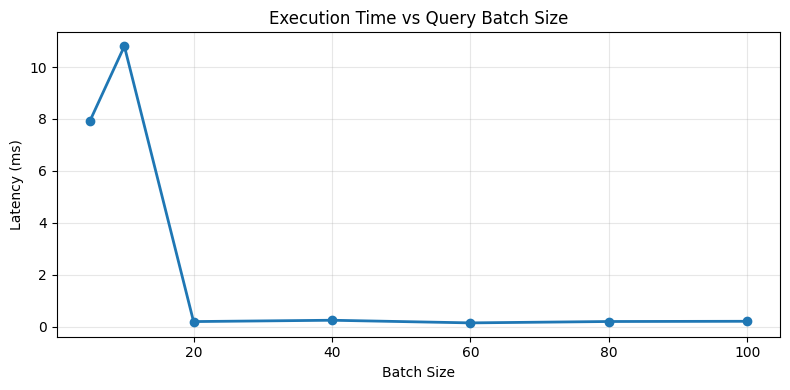

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(batch_sizes, timings_ms, marker="o", linewidth=2)
plt.title("Execution Time vs Query Batch Size")
plt.xlabel("Batch Size")
plt.ylabel("Latency (ms)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part 6 — Evaluation

In [20]:
# Quantitative metric: Precision@5 by Ticket Type
def precision_at_k(result_ids, true_label, k=5):
    top = result_ids[:k]
    if not top:
        return 0.0
    hits = sum(1 for idx in top if str(df.iloc[idx]["Ticket Type"]) == true_label)
    return hits / k

eval_queries = [
    ("payment failed charged twice", "Billing inquiry"),
    ("refund not processed yet", "Refund request"),
    ("cannot login account", "Technical issue"),
    ("wifi keeps disconnecting", "Technical issue"),
    ("product not delivered", "Product inquiry"),
    ("want to cancel order", "Cancellation request"),
]

rows = []
for q, true_type in eval_queries:
    tf = sparse_tfidf_search(q, top_k=5)[0]
    sm = semantic_search(q, top_k=5)[0]
    hy = hybrid_search(q, alpha=0.4, top_k=5)

    tf_ids = [i for i, _ in tf]
    sm_ids = [i for i, _ in sm]
    hy_ids = [i for i, _ in hy]

    rows.append({
        "query": q,
        "true_type": true_type,
        "P@5_TFIDF": precision_at_k(tf_ids, true_type, 5),
        "P@5_Semantic": precision_at_k(sm_ids, true_type, 5),
        "P@5_Hybrid": precision_at_k(hy_ids, true_type, 5),
    })

eval_df = pd.DataFrame(rows)
display(eval_df)
print("Mean P@5:")
print(eval_df[["P@5_TFIDF", "P@5_Semantic", "P@5_Hybrid"]].mean())

,query,true_type,P@5_TFIDF,P@5_Semantic,P@5_Hybrid
0,payment failed charged twice,Billing inquiry,0.0,0.0,0.0
1,refund not processed yet,Refund request,0.4,0.2,0.4
2,cannot login account,Technical issue,0.0,0.0,0.0
3,wifi keeps disconnecting,Technical issue,0.0,0.2,0.0
4,product not delivered,Product inquiry,0.6,0.4,0.6
5,want to cancel order,Cancellation request,0.0,0.0,0.0


Mean P@5:
P@5_TFIDF       0.166667
P@5_Semantic    0.133333
P@5_Hybrid      0.166667
dtype: float64


In [21]:
# 5 qualitative examples where semantic reasoning helps query intent matching
qual_queries = [
    "money returned not received",
    "laptop wont start after patch",
    "cannot access my profile anymore",
    "internet connection keeps dropping",
    "lost files after crash",
]

for q in qual_queries:
    tf_top = sparse_tfidf_search(q, top_k=1)[0]
    sm_top = semantic_search(q, top_k=1)[0]

    print("\nQuery:", q)
    if tf_top:
        i, s = tf_top[0]
        print(f"TF-IDF  -> score={s:.4f}, type={df.iloc[i]['Ticket Type']}, subject={df.iloc[i]['Ticket Subject']}")
    if sm_top:
        i, s = sm_top[0]
        print(f"Semantic-> score={s:.4f}, type={df.iloc[i]['Ticket Type']}, subject={df.iloc[i]['Ticket Subject']}")


Query: money returned not received
TF-IDF  -> score=0.4860, type=Cancellation request, subject=Delivery problem
Semantic-> score=0.9204, type=Cancellation request, subject=Delivery problem

Query: laptop wont start after patch
TF-IDF  -> score=0.3211, type=Cancellation request, subject=Product compatibility
Semantic-> score=0.8235, type=Technical issue, subject=Hardware issue

Query: cannot access my profile anymore
TF-IDF  -> score=0.4557, type=Cancellation request, subject=Battery life
Semantic-> score=0.8753, type=Product inquiry, subject=Refund request

Query: internet connection keeps dropping
TF-IDF  -> score=0.6044, type=Cancellation request, subject=Software bug
Semantic-> score=0.9332, type=Billing inquiry, subject=Hardware issue

Query: lost files after crash
TF-IDF  -> score=0.4906, type=Refund request, subject=Display issue
Semantic-> score=0.7595, type=Product inquiry, subject=Refund request


## Part 7 — Visualization Dashboard

These plots summarize:
- ticket distribution,
- model quality comparison,
- and score behavior for a sample query.

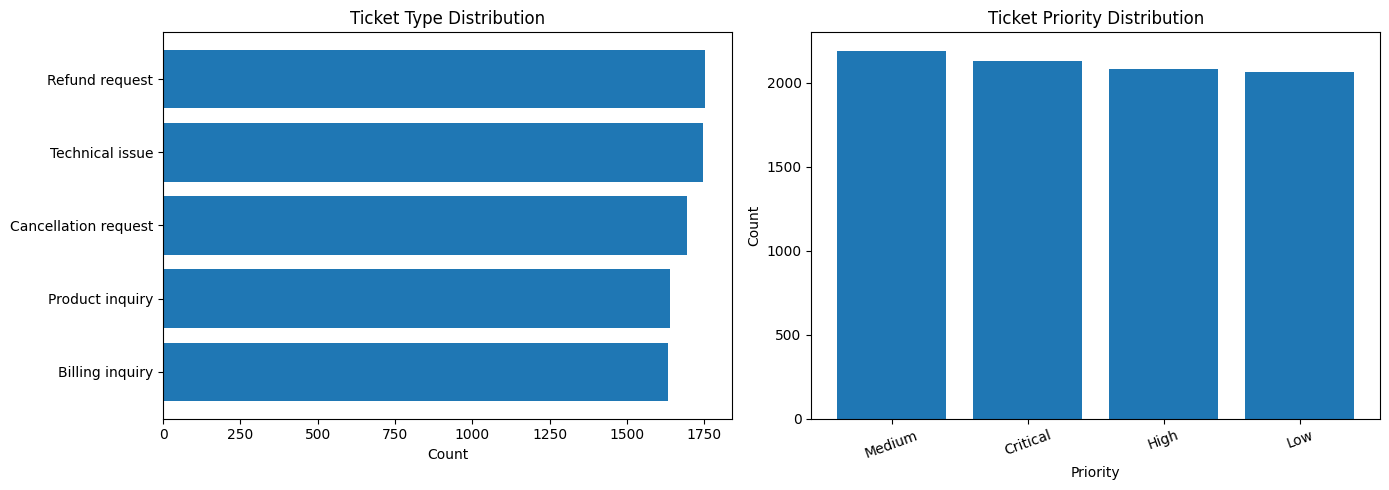

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# 1) Dataset composition: Ticket Type and Ticket Priority
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_counts = df["Ticket Type"].fillna("Unknown").astype(str).value_counts().sort_values(ascending=True)
axes[0].barh(type_counts.index, type_counts.values)
axes[0].set_title("Ticket Type Distribution")
axes[0].set_xlabel("Count")

priority_counts = df["Ticket Priority"].fillna("Unknown").astype(str).value_counts()
axes[1].bar(priority_counts.index, priority_counts.values)
axes[1].set_title("Ticket Priority Distribution")
axes[1].set_xlabel("Priority")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

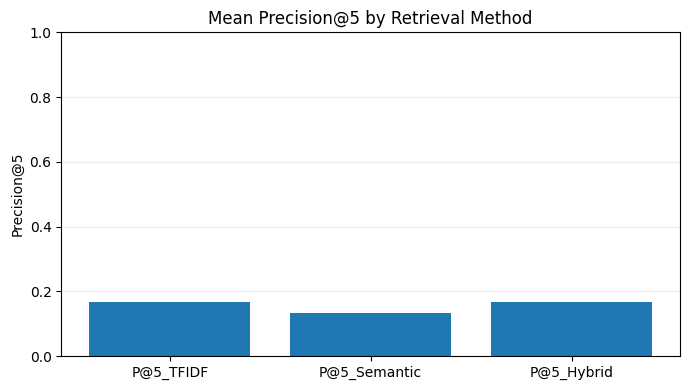

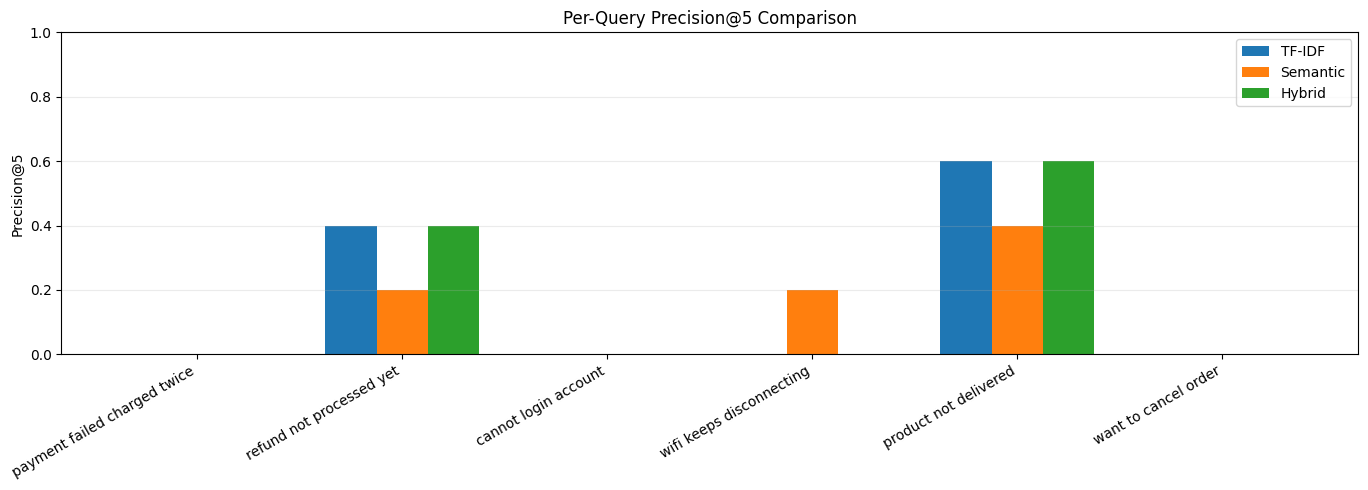

In [26]:
# 2) Evaluation comparison plots (requires eval_df from Part 6)
if "eval_df" not in globals():
    raise RuntimeError("Run Part 6 (evaluation cell) first to create eval_df.")

plot_df = eval_df.copy()
plot_df = plot_df[["query", "P@5_TFIDF", "P@5_Semantic", "P@5_Hybrid"]]

# Mean performance bar chart
means = plot_df[["P@5_TFIDF", "P@5_Semantic", "P@5_Hybrid"]].mean()
plt.figure(figsize=(7, 4))
plt.bar(means.index, means.values)
plt.ylim(0, 1)
plt.title("Mean Precision@5 by Retrieval Method")
plt.ylabel("Precision@5")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# Per-query grouped bars
x = np.arange(len(plot_df))
w = 0.25

plt.figure(figsize=(14, 5))
plt.bar(x - w, plot_df["P@5_TFIDF"], width=w, label="TF-IDF")
plt.bar(x,     plot_df["P@5_Semantic"], width=w, label="Semantic")
plt.bar(x + w, plot_df["P@5_Hybrid"], width=w, label="Hybrid")
plt.ylim(0, 1)
plt.xticks(x, plot_df["query"], rotation=30, ha="right")
plt.ylabel("Precision@5")
plt.title("Per-Query Precision@5 Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

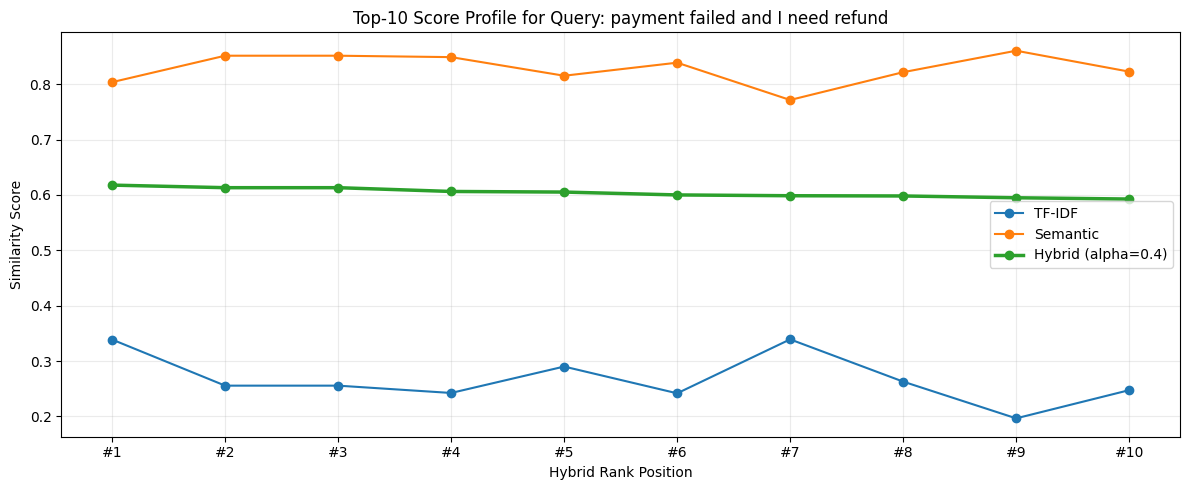

,hybrid_rank,doc_id,Ticket Type,Ticket Subject,tfidf_score,semantic_score,hybrid_score
0,1,2602,Cancellation request,Refund request,0.338876,0.803800,0.617830
1,2,4751,Cancellation request,Refund request,0.255646,0.851542,0.613183
2,3,2279,Cancellation request,Refund request,0.255646,0.851542,0.613183
3,4,7454,Technical issue,Refund request,0.242423,0.848967,0.606349
4,5,6230,Product inquiry,Hardware issue,0.290119,0.815372,0.605271
5,6,645,Refund request,Refund request,0.241811,0.838943,0.600090
6,7,7020,Cancellation request,Refund request,0.339238,0.771586,0.598646
7,8,3480,Technical issue,Payment issue,0.262935,0.821768,0.598235
8,9,231,Technical issue,Account access,0.196597,0.860557,0.594973
9,10,3307,Technical issue,Payment issue,0.247486,0.822787,0.592666


In [27]:
# 3) Score profile visualization for one sample query
sample_query = "payment failed and I need refund"
top_k = 10

# Collect raw score vectors similar to hybrid_search internals
tfidf_ranked, _ = sparse_tfidf_search(sample_query, top_k=len(df))
sem_ranked, _ = semantic_search(sample_query, top_k=len(df))

tfidf_scores = np.zeros(len(df), dtype=np.float32)
sem_scores = np.zeros(len(df), dtype=np.float32)
for i, s in tfidf_ranked:
    tfidf_scores[i] = s
for i, s in sem_ranked:
    sem_scores[i] = s

alpha = 0.4
hyb_scores = alpha * tfidf_scores + (1 - alpha) * sem_scores
top_idx = np.argsort(-hyb_scores)[:top_k]

labels = [f"#{rank+1}" for rank in range(top_k)]
tf_top = tfidf_scores[top_idx]
sm_top = sem_scores[top_idx]
hy_top = hyb_scores[top_idx]

plt.figure(figsize=(12, 5))
plt.plot(labels, tf_top, marker="o", label="TF-IDF")
plt.plot(labels, sm_top, marker="o", label="Semantic")
plt.plot(labels, hy_top, marker="o", linewidth=2.5, label="Hybrid (alpha=0.4)")
plt.title(f"Top-{top_k} Score Profile for Query: {sample_query}")
plt.xlabel("Hybrid Rank Position")
plt.ylabel("Similarity Score")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

score_table = pd.DataFrame({
    "hybrid_rank": np.arange(1, top_k + 1),
    "doc_id": top_idx,
    "Ticket Type": [df.iloc[i]["Ticket Type"] for i in top_idx],
    "Ticket Subject": [df.iloc[i]["Ticket Subject"] for i in top_idx],
    "tfidf_score": tf_top,
    "semantic_score": sm_top,
    "hybrid_score": hy_top,
})

display(score_table)

## Final Notes

- dictionary-based sparse TF-IDF + inverted index retrieval
- lightweight stem-rule tokenizer
- 100d IDF-weighted semantic embeddings
- hybrid fusion exactly as assignment formula with alpha=0.4
- batched query performance profiling